# Localization Simulation

Benchmark four trackers on one distance/angle localization scenario: the classical **CEKF** (centralized) and **DEKF** (diffusion) extended Kalman filters, the learned **Distributed KalmanNet**, and an optional **GNN-RNN** baseline.

Everything is driven by a trained experiment's `run.log`, and every figure is written to `<experiment>/notebook_plots/`.

Position error is reported throughout as **PMSE (dB)**: `10 * log10` of the mean Euclidean position error, matching the metric the models are trained on.

**Segments**
1. Setup & imports
2. Experiment selection
3. Scenario setup & visualization
4. Monte Carlo study (noise sweep)
5. dt-mismatch robustness
6. Node-count generalization
7. Connectivity generalization
8. Time-step generalization
9. Inference-latency comparison

## 1. Setup & Imports

Load libraries, add the repository root to `sys.path`, and import the localization helpers - system/observation models, the classical filters, the Distributed KalmanNet and GNN-RNN builders, checkpoint-path utilities, and plotting functions - used throughout the notebook.

In [10]:
import importlib
from copy import deepcopy
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "utils").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

torch.set_default_dtype(torch.float32)

import experiments.localization_experiment as localization_experiment_module
import utils.LocalizationScenario as localization_scenario_module
import utils.BaselineModels as baseline_models_module
importlib.reload(localization_scenario_module)
importlib.reload(localization_experiment_module)
importlib.reload(baseline_models_module)

from experiments.graphkalmanprocess_hparams import LOCALIZATION_BASELINE
from experiments.localization_experiment import (
    build_dkn_model,
    build_gnn_rnn_model,
    derive_localization_noise,
    dkn_model_path,
    dkn_run_name,
    gnn_rnn_model_path,
    list_experiments,
    load_state_dict_checked,
    load_experiment_config,
    localization_model_name,
    measurement_noise_for_nodes,
    plot_graph,
    plot_trajectory_and_nodes,
    predict_gnn_rnn,
)
from utils.ClassicDistributedKalman import (
    centralized_extended_kalman_filter,
    diffusion_extended_kalman_filter_parallel_edge,
)
from utils.LocalizationScenario import (
    ConstantVelocityModel,
    DistanceAngleObservation,
    build_graph_data_for_dkn,
    create_distance_based_graph,
    experiment_time_steps,
    farthest_mismatch_dt_ratio,
    format_dt_ratio,
    generate_measurements,
    generate_node_positions,
    generate_trajectory,
    generate_trial_data,
    nearest_nominal_dt_ratio,
    position_error_from_dekf,
    position_error_from_state_sequence,
    sync_torch_device,
)
from utils.reproducibility import seed_everything

# Legend and table name for the learned model, matching the other simulation notebooks.
DKN_LABEL = "Distributed KalmanNet"

# Shared figure scheme for every plot in this notebook: colour identifies the
# model, marker identifies the process-model condition. GNN-RNN has no
# matched/mismatched pair, so it keeps a diamond on a dotted line. Both the short
# key and the display name are registered for DKN so cells can use either.
MODEL_COLORS = {
    "CEKF": "#800080",
    "DEKF": "#FF0000",
    "DKN": "#0000FF",
    DKN_LABEL: "#0000FF",
    "GNN-RNN": "#008000",
}
CONDITION_MARKERS = {"matched": "s", "mismatched": "o"}


def model_color(label):
    """Resolve the shared colour from a label that may carry a suffix."""
    for name, color in MODEL_COLORS.items():
        if label.startswith(name):
            return color
    raise KeyError(f"no colour registered for {label!r}")


def model_style(model, condition="matched"):
    """Colour, marker and linestyle for one model in one process-model condition."""
    if model == "GNN-RNN":
        return {"color": MODEL_COLORS["GNN-RNN"], "marker": "d", "linestyle": ":"}
    return {
        "color": model_color(model),
        "marker": CONDITION_MARKERS[condition],
        "linestyle": "-" if condition == "matched" else "--",
    }


## 2. Experiment Selection

Pick a load folder (`my_models` or `models/_localization`), then list the trained `experiment_*` folders under it and print each one's key settings. The next segment loads the chosen experiment; its `run.log` alone drives the whole comparison. Training still writes new runs to `LOCALIZATION_BASELINE["save_root"]` (`my_models`).

In [11]:
base_config = deepcopy(LOCALIZATION_BASELINE)

# Load-folder options (training save_root stays my_models).
LOAD_ROOT_OPTIONS = {
    1: "my_models",
    2: "models/_localization",
}
LOAD_ROOT_CHOICE = 2  # 1 = my_models, 2 = models/_localization

if LOAD_ROOT_CHOICE not in LOAD_ROOT_OPTIONS:
    raise ValueError(f"LOAD_ROOT_CHOICE must be one of {sorted(LOAD_ROOT_OPTIONS)}")

save_root = REPO_ROOT / LOAD_ROOT_OPTIONS[LOAD_ROOT_CHOICE]
print(f"Loading experiments from: {save_root.relative_to(REPO_ROOT)}")
print(f"(training save_root remains: {base_config['save_root']})")

experiments = list_experiments(save_root)
if not experiments:
    raise RuntimeError(f"No experiment_* folders found under {save_root}")

print("Available experiments:")
for i, exp in enumerate(experiments, start=1):
    tag = ""
    description = ""
    try:
        ecfg = load_experiment_config(exp)
    except FileNotFoundError:
        ecfg = None
    if ecfg is not None:
        exp_title = ecfg.get("title", "")
        title_str = f' - "{exp_title}"' if exp_title else ""
        tag = f"  (T={experiment_time_steps(ecfg)}, lr={ecfg.get('learning_rate','?')}){title_str}"
        description = ecfg.get("description", "")
    print(f"  [{i}] {exp.name}{tag}")
    if description:
        print(f"      {description}")


Loading experiments from: models/_localization
(training save_root remains: my_models)
Available experiments:
  [1] experiment_1  (T=20, lr=0.0001)
      Baseline: curriculum on with epoch_per_step=20, r sweep 0.25-4, dt mismatch 1/2/5, dkn + gnn_rnn
  [2] experiment_2  (T=20, lr=0.0001)
      Baseline: No curriculum. 100 mox_epochs


## 3. Scenario Setup & Visualization

Load the selected experiment's config and rebuild the scenario it was trained on: constant-velocity dynamics, distance/angle sensors, and the sensor graph. Available Distributed KalmanNet / GNN-RNN checkpoints are discovered, the output folder `notebook_plots/` is created, and the sensor graph plus a sample trajectory are plotted so the geometry is clear before benchmarking.

Loaded experiment: experiment_2
seed                                                                    42
save_root                                                        my_models
state_dimension                                                          4
area_size                                                            100.0
x0                                                  [0.0, 50.0, 0.0, 50.0]
time_delta                                                             0.1
mu                                                                     1.0
rho                                                              32.828064
r_scale                                         [0.25, 0.5, 1.0, 2.0, 4.0]
p0_scale                                                              10.0
use_dt_mismatch                                                       True
dt_mismatch_values                                         [1.0, 2.0, 5.0]
num_nodes                                                           

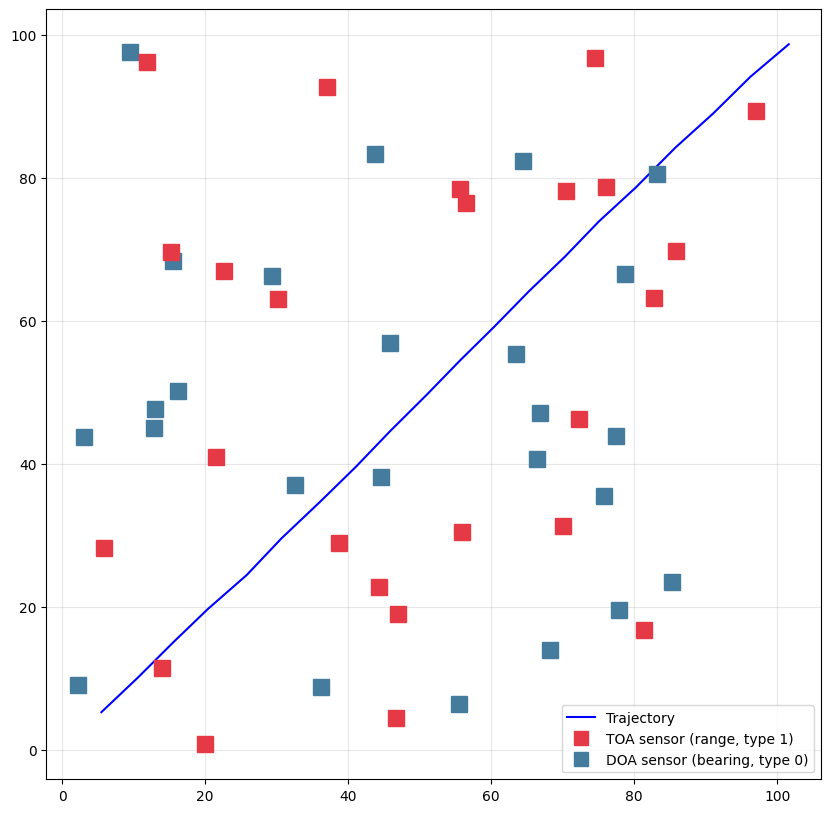

In [12]:
EXPERIMENT = 2
MISMATCH_DT_RATIO = 2.0  # dt ratio for the mismatched runs; must be in dt_mismatch_values
TEST_TIME_STEPS = 20    # horizon every model is evaluated on

if not 1 <= EXPERIMENT <= len(experiments):
    raise ValueError(f"EXPERIMENT must be in [1, {len(experiments)}], got {EXPERIMENT}")
experiment_dir = experiments[EXPERIMENT - 1]
config_val = load_experiment_config(experiment_dir)
print(f"Loaded experiment: {experiment_dir.name}")
print(pd.Series(config_val))

seed_everything(config_val["seed"])

num_nodes = config_val["num_nodes"]
use_dt_mismatch = config_val.get("use_dt_mismatch", False)
dt_mismatch_values = config_val.get("dt_mismatch_values", [1.0])
default_dkn_dt_ratio = nearest_nominal_dt_ratio(dt_mismatch_values) if use_dt_mismatch else None

if not use_dt_mismatch:
    mismatch_dt_ratio = None
elif MISMATCH_DT_RATIO is None:
    mismatch_dt_ratio = farthest_mismatch_dt_ratio(dt_mismatch_values, default_dkn_dt_ratio)
elif any(np.isclose(float(MISMATCH_DT_RATIO), float(value)) for value in dt_mismatch_values):
    mismatch_dt_ratio = float(MISMATCH_DT_RATIO)
else:
    raise ValueError(
        f"MISMATCH_DT_RATIO={MISMATCH_DT_RATIO} is not in dt_mismatch_values={dt_mismatch_values}"
    )

state_dimension = config_val["state_dimension"]
x_init = np.array(config_val["x0"], dtype=float).reshape(state_dimension, 1)
p0 = np.eye(state_dimension) * config_val["p0_scale"]


def sample_initial_state(mean, covariance):
    """Sample the true initial state from N(mean, covariance)."""
    sample = np.random.multivariate_normal(mean[:, 0], covariance)
    return sample.reshape(mean.shape)


train_time_steps = experiment_time_steps(config_val)
num_time_steps = train_time_steps if TEST_TIME_STEPS is None else int(TEST_TIME_STEPS)
num_trials = config_val["num_trials"]
time_delta = config_val["time_delta"]
measurement_noise_values = config_val["r_scale"]
node_positions = np.array(config_val["node_positions"], dtype=float)
f_system = ConstantVelocityModel(time_delta)
f_system_dkn = ConstantVelocityModel(time_delta * float(default_dkn_dt_ratio)) if use_dt_mismatch else f_system
h_system = DistanceAngleObservation(node_positions)
node_types = h_system.node_classification[:, 0].numpy().astype(int)

def noise_for_scale(r_scale):
    return derive_localization_noise(config_val["mu"], config_val["rho"], r_scale)

def r_array_for(observation_model, r_scale):
    noise = noise_for_scale(r_scale)
    return measurement_noise_for_nodes(observation_model, noise["sigma_r"], noise["sigma_theta"])

adjacency_matrix = create_distance_based_graph(
    node_positions,
    k_neighbors=config_val["k_neighbors"],
    seed=config_val["graph_seed"],
)
j_matrix = np.array(adjacency_matrix, dtype=float, copy=True)
np.fill_diagonal(j_matrix, 1.0)

dkn_dir = experiment_dir
gnn_rnn_dir = experiment_dir / "gnn-rnn"
available_noise_values = [
    r for r in measurement_noise_values
    if dkn_model_path(
        experiment_dir,
        r,
        use_dt_mismatch=use_dt_mismatch,
        default_dt_ratio=default_dkn_dt_ratio,
    ).exists()
]
missing_noise_values = [r for r in measurement_noise_values if r not in available_noise_values]
if missing_noise_values:
    print(f"Warning: missing DKN checkpoints for r={missing_noise_values} in {dkn_dir} - skipping.")
if not available_noise_values:
    raise RuntimeError(f"No DKN checkpoints found in {dkn_dir}")

gnn_rnn_available_noise_values = [r for r in available_noise_values if gnn_rnn_model_path(experiment_dir, r).exists()]
missing_gnn_rnn_noise_values = [r for r in available_noise_values if r not in gnn_rnn_available_noise_values]
if missing_gnn_rnn_noise_values:
    print(f"Warning: missing GNN-RNN checkpoints for r={missing_gnn_rnn_noise_values} in {gnn_rnn_dir} - omitting GNN-RNN for those rows.")
use_gnn_rnn = len(gnn_rnn_available_noise_values) > 0
measurement_noise_values = available_noise_values

notebook_plot_dir = experiment_dir / "notebook_plots"
notebook_plot_dir.mkdir(parents=True, exist_ok=True)

print(f"Train nodes:      {num_nodes}")
print(f"Time steps:       train {train_time_steps} -> test {num_time_steps}")
if use_dt_mismatch:
    print(f"DKN checkpoint dt ratio for non-mismatch sections: {default_dkn_dt_ratio}")
    print(f"Mismatch dt ratio: {mismatch_dt_ratio} (choices: {dt_mismatch_values})")
plot_graph(adjacency_matrix, node_positions, title="")
preview_noise = noise_for_scale(measurement_noise_values[0])
plot_trajectory_and_nodes(
    node_positions,
    node_types,
    generate_trajectory(f_system, x_init, num_time_steps, preview_noise["q_matrix"]),
    title="",
)


## 4. Monte Carlo Study (Noise Sweep)

For each measurement-noise level, average the position error over paired random trials. CEKF, DEKF, and Distributed KalmanNet are evaluated with matched and mismatched `dt` dynamics, while GNN-RNN (no explicit dynamics) is evaluated once. The notebook produces one noise-sweep figure: **PMSE (dB)** against inverse noise variance **$1/r^2$ (dB)**.

In [13]:
if use_dt_mismatch:
    MONTE_CARLO_NO_MISMATCH_RATIO = float(default_dkn_dt_ratio)
    MONTE_CARLO_MISMATCH_RATIO = float(mismatch_dt_ratio)
    monte_carlo_dt_ratios = list(dict.fromkeys([
        MONTE_CARLO_NO_MISMATCH_RATIO,
        MONTE_CARLO_MISMATCH_RATIO,
    ]))
    print(
        "Monte Carlo dt ratios: "
        f"no mismatch={format_dt_ratio(MONTE_CARLO_NO_MISMATCH_RATIO)}, "
        f"mismatch={format_dt_ratio(MONTE_CARLO_MISMATCH_RATIO)}"
    )
else:
    # dt_mismatch_values is ignored for matched runs; it may hold a stale ratio.
    MONTE_CARLO_NO_MISMATCH_RATIO = 1.0
    MONTE_CARLO_MISMATCH_RATIO = None
    monte_carlo_dt_ratios = [MONTE_CARLO_NO_MISMATCH_RATIO]
    print("No dt-mismatch experiment is configured; evaluating nominal dynamics only.")

monte_carlo_display_names = {"CEKF": "CEKF", "DEKF": "DEKF", "DKN": DKN_LABEL}


def monte_carlo_label(model_name, ratio):
    display_name = monte_carlo_display_names[model_name]
    if MONTE_CARLO_MISMATCH_RATIO is None:
        return display_name
    condition = "matched" if ratio == MONTE_CARLO_NO_MISMATCH_RATIO else "mismatched"
    return f"{display_name} ({condition})"


monte_carlo_labels = {
    model_name: {
        ratio: monte_carlo_label(model_name, ratio)
        for ratio in monte_carlo_dt_ratios
    }
    for model_name in ["CEKF", "DEKF", "DKN"]
}
monte_carlo_series = [
    monte_carlo_labels[model_name][ratio]
    for model_name in ["CEKF", "DEKF", "DKN"]
    for ratio in monte_carlo_dt_ratios
] + ["GNN-RNN"]

avg_errors = {label: [] for label in monte_carlo_series}

for r_noise in measurement_noise_values:
    noise = noise_for_scale(r_noise)
    r_array = r_array_for(h_system, r_noise)

    dkn_processes = {}
    for dt_ratio in monte_carlo_dt_ratios:
        model_path = dkn_model_path(experiment_dir, r_noise, use_dt_mismatch=use_dt_mismatch, dt_ratio=dt_ratio)
        if not model_path.exists():
            raise FileNotFoundError(f"Missing DKN checkpoint for Monte Carlo comparison: {model_path}")
        f_model_ratio = ConstantVelocityModel(time_delta * float(dt_ratio))
        kalman_process = build_dkn_model(config_val, f_model_ratio, r_array, x_init)
        dkn_processes[dt_ratio] = load_state_dict_checked(kalman_process, model_path)

    gnn_rnn_process = None
    gnn_path = gnn_rnn_model_path(experiment_dir, r_noise)
    if gnn_path.exists():
        gnn_rnn_process = build_gnn_rnn_model(config_val)
        gnn_rnn_process = load_state_dict_checked(gnn_rnn_process, gnn_path)
    else:
        print(f"No GNN-RNN checkpoint found for r={r_noise}; GNN-RNN result will be NaN.")

    trial_errors = {label: [] for label in monte_carlo_series}

    for _ in tqdm(range(num_trials), desc=f"r={r_noise}"):
        true_x0 = sample_initial_state(x_init, p0)
        trajectory, measurements = generate_trial_data(
            f_system, h_system, true_x0, num_time_steps, noise["q_matrix"], r_array
        )
        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)

        for dt_ratio in monte_carlo_dt_ratios:
            f_model_ratio = ConstantVelocityModel(time_delta * float(dt_ratio))
            x_hat_cekf = centralized_extended_kalman_filter(
                measurements=measurements,
                f_system=f_model_ratio,
                h_system=h_system,
                r_array=r_array,
                q=noise["q"],
                p0=p0,
                x0=x_init,
                time_steps=num_time_steps,
                node_num=num_nodes,
                q_matrix=noise["q_matrix"],
            )
            x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
                measurements=measurements,
                f_system=f_model_ratio,
                h_system=h_system,
                r_array=r_array,
                q=noise["q"],
                p0=p0,
                x0=x_init,
                j_matrix=j_matrix,
                time_steps=num_time_steps,
                node_num=num_nodes,
                q_matrix=noise["q_matrix"],
            )
            with torch.no_grad():
                x_hat_dkn = dkn_processes[dt_ratio](graph_data)[0].mean(dim=1)[..., 0].cpu().numpy()

            trial_errors[monte_carlo_labels["CEKF"][dt_ratio]].append(position_error_from_state_sequence(trajectory, x_hat_cekf[:, :, 0]))
            trial_errors[monte_carlo_labels["DEKF"][dt_ratio]].append(position_error_from_dekf(trajectory, x_hat_dekf))
            trial_errors[monte_carlo_labels["DKN"][dt_ratio]].append(position_error_from_state_sequence(trajectory, x_hat_dkn))

        if gnn_rnn_process is not None:
            x_hat_gnn_rnn = predict_gnn_rnn(gnn_rnn_process, graph_data, h_system)
            trial_errors["GNN-RNN"].append(position_error_from_state_sequence(trajectory, x_hat_gnn_rnn))

    for label in monte_carlo_series:
        avg_errors[label].append(np.mean(trial_errors[label]) if trial_errors[label] else np.nan)

results_df = pd.DataFrame(
    {
        "measurement_noise": measurement_noise_values,
        **avg_errors,
    }
)
results_df


Monte Carlo dt ratios: no mismatch=1.0, mismatch=2.0


r=4.0: 100%|██████████| 50/50 [00:24<00:00,  2.03it/s]


,measurement_noise,CEKF (matched),CEKF (mismatched),DEKF (matched),DEKF (mismatched),Distributed KalmanNet (matched),Distributed KalmanNet (mismatched),GNN-RNN
0,0.25,0.179949,0.399775,3.830930,40.637340,0.152898,0.168021,1.185932
1,0.50,0.316609,0.554168,4.313159,36.993647,0.313664,0.325116,1.002687
2,1.00,0.606555,0.778994,5.173568,35.625788,0.667405,0.689237,1.663329
3,2.00,1.032406,1.166303,6.951044,34.544874,1.392968,1.373792,2.272588
4,4.00,1.961633,2.094066,16.374174,39.844502,3.362166,3.913362,4.883377


Saved position-error plot: /Users/inega/Python/kalmanet2/distributedKNET/models/_localization/experiment_2/notebook_plots/position_error_vs_inverse_r2_trials=50_T=20.png


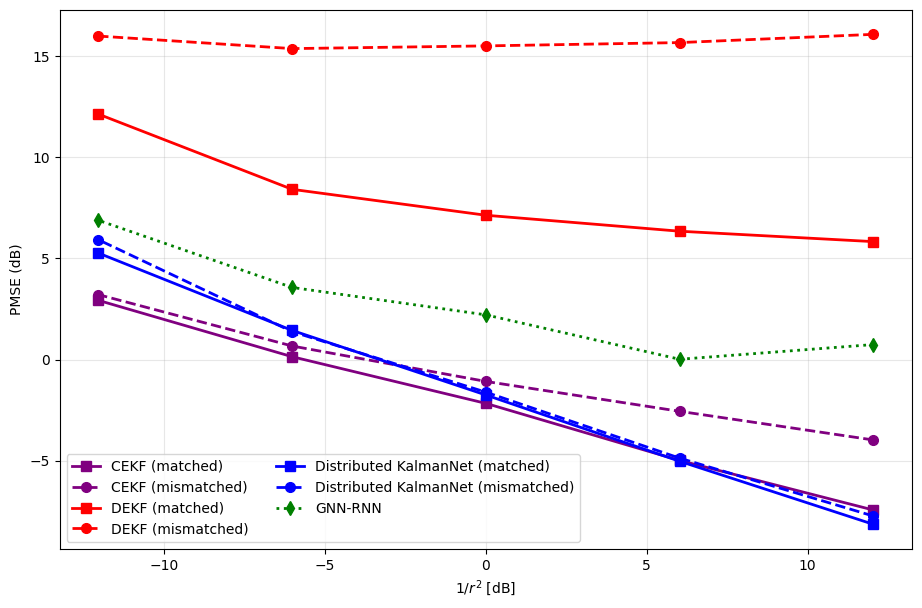

In [14]:
summary_plot_path = notebook_plot_dir / f"position_error_vs_inverse_r2_trials={num_trials}_T={num_time_steps}.png"
monte_carlo_plot_styles = {
    monte_carlo_labels[model_name][ratio]: model_style(
        monte_carlo_display_names[model_name],
        "matched" if ratio == MONTE_CARLO_NO_MISMATCH_RATIO else "mismatched",
    )
    for model_name in ["CEKF", "DEKF", "DKN"]
    for ratio in monte_carlo_dt_ratios
}
monte_carlo_plot_styles["GNN-RNN"] = model_style("GNN-RNN")

inv_r2_db = 10 * np.log10(1.0 / results_df["measurement_noise"] ** 2)

plt.figure(figsize=(11, 7))
for label, style in monte_carlo_plot_styles.items():
    if label in results_df.columns and results_df[label].notna().any():
        plt.plot(
            inv_r2_db,
            10 * np.log10(results_df[label]),
            linewidth=2,
            markersize=7,
            label=label,
            **style,
        )
plt.xlabel(r"$1/r^2$ [dB]")
plt.ylabel("PMSE (dB)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.savefig(summary_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved position-error plot: {summary_plot_path}")
plt.show()

## 5. dt-Mismatch Robustness

Fix the measurement noise and sweep the `dt` mismatch multiplier. Data always uses the true `time_delta`; each filter instead runs with `time_delta x ratio`, and the Distributed KalmanNet checkpoint trained at each ratio is loaded (the GNN-RNN checkpoint, if present, is reused for every ratio).

Only a couple of mismatch ratios are configured, so the results are reported as a table in PMSE (dB) rather than a plot.

In [15]:
R_MISMATCH_EVAL = 1.0
mismatch_experiment_dir = experiment_dir
mismatch_config = config_val
if mismatch_config.get("use_dt_mismatch", False):
    dt_mismatch_values = mismatch_config.get("dt_mismatch_values", [1.0])
else:
    dt_mismatch_values = [1.0]
    print("No dt-mismatch experiment is configured; evaluating nominal dynamics only.")

print(f"Experiment:         {mismatch_experiment_dir.name}")
print(f"dt_mismatch_values: {dt_mismatch_values}")
print(f"Evaluating at r={R_MISMATCH_EVAL}")

Experiment:         experiment_2
dt_mismatch_values: [1.0, 2.0, 5.0]
Evaluating at r=1.0


In [16]:
mismatch_errors_cekf = []
mismatch_errors_dekf = []
mismatch_errors_dkn = []
mismatch_errors_gnn_rnn = []

mismatch_noise = noise_for_scale(R_MISMATCH_EVAL)
r_array_mismatch = r_array_for(h_system, R_MISMATCH_EVAL)
f_data = ConstantVelocityModel(time_delta)
mismatch_gnn_rnn_process = None
mismatch_gnn_rnn_path = gnn_rnn_model_path(mismatch_experiment_dir, R_MISMATCH_EVAL)
if mismatch_gnn_rnn_path.exists():
    mismatch_gnn_rnn_process = build_gnn_rnn_model(mismatch_config)
    mismatch_gnn_rnn_process = load_state_dict_checked(mismatch_gnn_rnn_process, mismatch_gnn_rnn_path)
else:
    print(f"No GNN-RNN checkpoint found at {mismatch_gnn_rnn_path}; omitting GNN-RNN from mismatch sweep.")

for ratio in dt_mismatch_values:
    f_model_r = ConstantVelocityModel(time_delta * ratio)

    model_path = dkn_model_path(
        mismatch_experiment_dir,
        R_MISMATCH_EVAL,
        use_dt_mismatch=mismatch_config.get("use_dt_mismatch", False),
        dt_ratio=ratio,
    )
    kalman_process_m = build_dkn_model(mismatch_config, f_model_r, r_array_mismatch, x_init)
    kalman_process_m = load_state_dict_checked(kalman_process_m, model_path)

    trial_errors_cekf_m = []
    trial_errors_dekf_m = []
    trial_errors_dkn_m = []
    trial_errors_gnn_rnn_m = []

    for _ in tqdm(range(num_trials), desc=f"ratio={ratio}"):
        true_x0 = sample_initial_state(x_init, p0)
        trajectory = generate_trajectory(f_data, true_x0, num_time_steps, mismatch_noise["q_matrix"])
        measurements = generate_measurements(h_system, trajectory, r_array_mismatch)

        x_hat_cekf_m = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=f_model_r,
            h_system=h_system,
            r_array=r_array_mismatch,
            q=mismatch_noise["q"],
            p0=p0,
            x0=x_init,
            time_steps=num_time_steps,
            node_num=num_nodes,
            q_matrix=mismatch_noise["q_matrix"],
        )
        x_hat_dekf_m = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_model_r,
            h_system=h_system,
            r_array=r_array_mismatch,
            q=mismatch_noise["q"],
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
            q_matrix=mismatch_noise["q_matrix"],
        )

        graph_data = build_graph_data_for_dkn(adjacency_matrix, h_system, trajectory, measurements)
        with torch.no_grad():
            x_hat_dkn_m = kalman_process_m(graph_data)[0].mean(dim=1)[..., 0].cpu().numpy()
        x_hat_gnn_rnn_m = predict_gnn_rnn(mismatch_gnn_rnn_process, graph_data, h_system) if mismatch_gnn_rnn_process is not None else None

        x_true = trajectory[:, 0, 0].numpy()
        y_true = trajectory[:, 2, 0].numpy()

        x_cekf = x_hat_cekf_m[:, 0, 0]
        y_cekf = x_hat_cekf_m[:, 2, 0]
        trial_errors_cekf_m.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

        x_dekf = x_hat_dekf_m[:, :, 0, 0].mean(axis=1)
        y_dekf = x_hat_dekf_m[:, :, 2, 0].mean(axis=1)
        trial_errors_dekf_m.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

        trial_errors_dkn_m.append(np.sqrt((x_true - x_hat_dkn_m[:, 0]) ** 2 + (y_true - x_hat_dkn_m[:, 2]) ** 2).mean())
        if x_hat_gnn_rnn_m is not None:
            trial_errors_gnn_rnn_m.append(np.sqrt((x_true - x_hat_gnn_rnn_m[:, 0]) ** 2 + (y_true - x_hat_gnn_rnn_m[:, 2]) ** 2).mean())

    mismatch_errors_cekf.append(np.mean(trial_errors_cekf_m))
    mismatch_errors_dekf.append(np.mean(trial_errors_dekf_m))
    mismatch_errors_dkn.append(np.mean(trial_errors_dkn_m))
    mismatch_errors_gnn_rnn.append(np.mean(trial_errors_gnn_rnn_m) if trial_errors_gnn_rnn_m else np.nan)

mismatch_results_df = pd.DataFrame({
    "dt_mismatch": dt_mismatch_values,
    "CEKF": mismatch_errors_cekf,
    "DEKF": mismatch_errors_dekf,
    DKN_LABEL: mismatch_errors_dkn,
    "GNN-RNN": mismatch_errors_gnn_rnn,
})
# Too few mismatch ratios to justify a plot, so the table is reported directly.
mismatch_epsilon = np.finfo(float).tiny
for model_name in ["CEKF", "DEKF", DKN_LABEL, "GNN-RNN"]:
    mismatch_results_df[f"{model_name}_db"] = 10 * np.log10(
        np.maximum(mismatch_results_df[model_name], mismatch_epsilon)
    )

print(
    f"dt mismatch robustness in PMSE (dB) (r={R_MISMATCH_EVAL}, {num_trials} trials, "
    f"mu={config_val['mu']}, T={num_time_steps})"
)
mismatch_results_df

ratio=1.0:   0%|          | 0/50 [00:00<?, ?it/s]/Users/inega/Python/kalmanet2/distributedKNET/utils/LocalizationScenario.py:323: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(trajectory, dtype=torch.float32),
ratio=5.0: 100%|██████████| 50/50 [00:12<00:00,  3.90it/s]

dt mismatch robustness in PMSE (dB) (r=1.0, 50 trials, mu=1.0, T=20)


,dt_mismatch,CEKF,DEKF,Distributed KalmanNet,GNN-RNN,CEKF_db,DEKF_db,Distributed KalmanNet_db,GNN-RNN_db
0,1.0,0.571697,5.055736,0.650960,1.604255,-2.428344,7.037844,-1.864458,2.052735
1,2.0,0.767017,32.680363,0.664687,1.491207,-1.151949,15.142869,-1.773830,1.735379
2,5.0,1.598107,201.868932,8.070407,1.648903,2.036058,23.050695,9.068954,2.171950


### CEKF/DEKF severe dt-mismatch significance test

Evaluate the classical filters at every configured measurement-noise level with model dynamics `dt x1`, `dt x3`, `dt x5`, and `dt x10`; generated data always uses the true nominal `dt`. Each ratio sees the same 50 trajectories and measurements, enabling a paired bootstrap comparison against `dt x1`. A mismatch is marked significant when the 95% confidence interval for the paired PMSE change excludes zero.

In [17]:
CLASSICAL_DT_RATIOS = [1.0, 3.0, 5.0, 10.0]
CLASSICAL_DT_NOISE_LEVELS = [0.25, 0.5, 1.0, 2.0, 4.0]
CLASSICAL_DT_TRIALS = 50
CLASSICAL_DT_BOOTSTRAPS = 2_000


def paired_pmse_delta_ci(errors, baseline_errors, rng, n_resamples):
    errors = np.asarray(errors, dtype=float)
    baseline_errors = np.asarray(baseline_errors, dtype=float)
    indices = rng.integers(0, len(errors), size=(n_resamples, len(errors)))
    epsilon = np.finfo(float).tiny
    sampled_pmse = 10 * np.log10(np.maximum(errors[indices].mean(axis=1), epsilon))
    sampled_baseline = 10 * np.log10(
        np.maximum(baseline_errors[indices].mean(axis=1), epsilon)
    )
    return np.percentile(sampled_pmse - sampled_baseline, [2.5, 97.5])


classical_dt_rows = []
f_data_classical_dt = ConstantVelocityModel(time_delta)

for noise_idx, r_noise in enumerate(CLASSICAL_DT_NOISE_LEVELS):
    noise = noise_for_scale(r_noise)
    r_array = r_array_for(h_system, r_noise)

    # Generate once so every dt ratio and both filters see identical trials.
    seed_everything(int(config_val["seed"]) + 10_000 + noise_idx)
    trial_bank = []
    for _ in range(CLASSICAL_DT_TRIALS):
        true_x0 = sample_initial_state(x_init, p0)
        trajectory = generate_trajectory(
            f_data_classical_dt, true_x0, num_time_steps, noise["q_matrix"]
        )
        measurements = generate_measurements(h_system, trajectory, r_array)
        trial_bank.append((trajectory, measurements))

    errors_by_model = {
        "CEKF": {ratio: [] for ratio in CLASSICAL_DT_RATIOS},
        "DEKF": {ratio: [] for ratio in CLASSICAL_DT_RATIOS},
    }

    for ratio in CLASSICAL_DT_RATIOS:
        f_model = ConstantVelocityModel(time_delta * ratio)
        for trajectory, measurements in tqdm(
            trial_bank, desc=f"r={r_noise:g}, dt x{ratio:g}"
        ):
            x_hat_cekf = centralized_extended_kalman_filter(
                measurements=measurements,
                f_system=f_model,
                h_system=h_system,
                r_array=r_array,
                q=noise["q"],
                p0=p0,
                x0=x_init,
                time_steps=num_time_steps,
                node_num=num_nodes,
                q_matrix=noise["q_matrix"],
            )
            x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
                measurements=measurements,
                f_system=f_model,
                h_system=h_system,
                r_array=r_array,
                q=noise["q"],
                p0=p0,
                x0=x_init,
                j_matrix=j_matrix,
                time_steps=num_time_steps,
                node_num=num_nodes,
                q_matrix=noise["q_matrix"],
            )

            x_true = trajectory[:, 0, 0].numpy()
            y_true = trajectory[:, 2, 0].numpy()
            cekf_error = np.hypot(
                x_true - x_hat_cekf[:, 0, 0],
                y_true - x_hat_cekf[:, 2, 0],
            ).mean()
            dekf_error = np.hypot(
                x_true - x_hat_dekf[:, :, 0, 0].mean(axis=1),
                y_true - x_hat_dekf[:, :, 2, 0].mean(axis=1),
            ).mean()
            errors_by_model["CEKF"][ratio].append(cekf_error)
            errors_by_model["DEKF"][ratio].append(dekf_error)

    for model_idx, model_name in enumerate(["CEKF", "DEKF"]):
        baseline_errors = np.asarray(errors_by_model[model_name][1.0])
        baseline_pmse_db = 10 * np.log10(baseline_errors.mean())
        for ratio_idx, ratio in enumerate(CLASSICAL_DT_RATIOS):
            errors = np.asarray(errors_by_model[model_name][ratio])
            pmse_db = 10 * np.log10(errors.mean())
            if np.isclose(ratio, 1.0):
                ci_low_db = ci_high_db = 0.0
            else:
                bootstrap_rng = np.random.default_rng(
                    int(config_val["seed"])
                    + 20_000
                    + noise_idx * 100
                    + model_idx * 10
                    + ratio_idx
                )
                ci_low_db, ci_high_db = paired_pmse_delta_ci(
                    errors,
                    baseline_errors,
                    bootstrap_rng,
                    CLASSICAL_DT_BOOTSTRAPS,
                )
            classical_dt_rows.append({
                "measurement_noise": r_noise,
                "model": model_name,
                "dt_ratio": ratio,
                "PMSE_db": pmse_db,
                "delta_vs_dt1_db": pmse_db - baseline_pmse_db,
                "ci95_low_db": ci_low_db,
                "ci95_high_db": ci_high_db,
                "significant_vs_dt1": (
                    not np.isclose(ratio, 1.0)
                    and (ci_low_db > 0.0 or ci_high_db < 0.0)
                ),
            })

classical_dt_results_df = pd.DataFrame(classical_dt_rows)
assert len(classical_dt_results_df) == 40
assert np.isfinite(
    classical_dt_results_df[
        ["PMSE_db", "delta_vs_dt1_db", "ci95_low_db", "ci95_high_db"]
    ].to_numpy()
).all()

classical_dt_pmse_table = classical_dt_results_df.pivot(
    index="measurement_noise", columns=["model", "dt_ratio"], values="PMSE_db"
)
classical_dt_significance_df = classical_dt_results_df.loc[
    classical_dt_results_df["dt_ratio"] > 1.0,
    [
        "measurement_noise",
        "model",
        "dt_ratio",
        "PMSE_db",
        "delta_vs_dt1_db",
        "ci95_low_db",
        "ci95_high_db",
        "significant_vs_dt1",
    ],
].reset_index(drop=True)

print("PMSE (dB); lower is better")
display(classical_dt_pmse_table)
print("Paired change from dt x1 with bootstrap 95% confidence intervals")
display(classical_dt_significance_df)

r=4, dt x10: 100%|██████████| 50/50 [00:10<00:00,  4.77it/s]

PMSE (dB); lower is better


model                  CEKF                                      DEKF  \
dt_ratio               1.0       3.0       5.0        10.0       1.0    
measurement_noise                                                       
0.25              -7.066413 -2.519964 -1.996343   8.634872   6.101218   
0.50              -4.716936 -1.464909  0.344127  11.454803   6.418491   
1.00              -2.633464 -0.215442  2.029925  12.341525   7.151477   
2.00               0.227790  1.409555  3.335417  12.710697   8.940857   
4.00               3.079212  3.549997  5.023021  12.812194  12.407913   

model                                               
dt_ratio                3.0        5.0        10.0  
measurement_noise                                   
0.25               19.880594  23.154503  24.990033  
0.50               19.719852  23.175778  24.489269  
1.00               19.566401  23.014812  23.332488  
2.00               19.280692  22.539040  21.616074  
4.00               19.289120  22.283259  21.795361

Paired change from dt x1 with bootstrap 95% confidence intervals


,measurement_noise,model,dt_ratio,PMSE_db,delta_vs_dt1_db,ci95_low_db,ci95_high_db,significant_vs_dt1
0,0.25,CEKF,3.0,-2.519964,4.546449,4.020381,5.071559,True
1,0.25,CEKF,5.0,-1.996343,5.070070,4.611203,5.579600,True
2,0.25,CEKF,10.0,8.634872,15.701285,15.194540,16.250807,True
3,0.25,DEKF,3.0,19.880594,13.779376,13.243792,14.423105,True
4,0.25,DEKF,5.0,23.154503,17.053284,16.496058,17.661973,True
5,0.25,DEKF,10.0,24.990033,18.888815,18.336938,19.553175,True
6,0.50,CEKF,3.0,-1.464909,3.252027,2.825073,3.667108,True
7,0.50,CEKF,5.0,0.344127,5.061063,4.381911,5.750402,True
8,0.50,CEKF,10.0,11.454803,16.171739,15.760728,16.593072,True
9,0.50,DEKF,3.0,19.719852,13.301361,12.740999,13.882181,True


## 6. Node-Count Generalization

Evaluate the trained Distributed KalmanNet and optional GNN-RNN against fresh scenarios with different node counts (the graph is rebuilt for each size). This checks how well the learned models transfer beyond their training graph size; CEKF and DEKF are included as references.

nodes=10, layout=42:   0%|          | 0/50 [00:00<?, ?it/s]/Users/inega/Python/kalmanet2/distributedKNET/utils/LocalizationScenario.py:323: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(trajectory, dtype=torch.float32),
nodes=100, layout=45: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]

Saved: /Users/inega/Python/kalmanet2/distributedKNET/models/_localization/experiment_2/notebook_plots/node_count_generalization_r=1.0_dtx1.0_trainN=50_layouts=4_trials=50.png


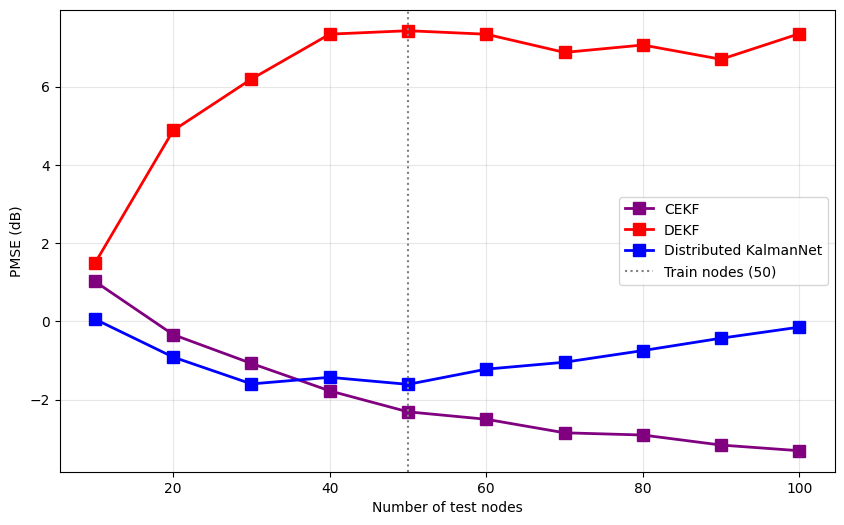

,test_num_nodes,CEKF,DEKF,Distributed KalmanNet,CEKF_db,DEKF_db,Distributed KalmanNet_db
0,10,1.264512,1.406362,1.012766,1.019229,1.480970,0.055092
1,20,0.924620,3.073384,0.810099,-0.340365,4.876168,-0.914618
2,30,0.780317,4.160889,0.691718,-1.077288,6.191861,-1.600708
3,40,0.664064,5.418014,0.719145,-1.777902,7.338402,-1.431834
4,50,0.586958,5.528421,0.689917,-2.313927,7.426011,-1.612032
5,60,0.561788,5.415897,0.754503,-2.504277,7.336704,-1.223391
6,70,0.518816,4.865751,0.785873,-2.849869,6.871499,-1.046476
7,80,0.512065,5.082471,0.841732,-2.906752,7.060749,-0.748264
8,90,0.482677,4.672853,0.905336,-3.163431,6.695821,-0.431902
9,100,0.466867,5.433916,0.966262,-3.308066,7.351129,-0.149051


In [24]:
TEST_NUM_NODES_VALUES = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# Each point averages NODE_COUNT_NUM_TRIALS trials on each of several sensor
# layouts. One layout per node count leaves the curve dominated by the geometry of
# that particular draw rather than by node count, so neighbouring points swap
# order. Runtime scales with the product of these two.
NODE_COUNT_LAYOUT_SEEDS = [config_val["graph_seed"] + offset for offset in range(4)]
NODE_COUNT_NUM_TRIALS = num_trials

train_num_nodes = num_nodes
NODE_COUNT_R_EVAL = 1.0
NODE_COUNT_DKN_DT_RATIO = default_dkn_dt_ratio if use_dt_mismatch else None
node_count_run_name = dkn_run_name(NODE_COUNT_R_EVAL, use_dt_mismatch=use_dt_mismatch, dt_ratio=NODE_COUNT_DKN_DT_RATIO)
node_count_model_path = dkn_model_path(experiment_dir, NODE_COUNT_R_EVAL, use_dt_mismatch=use_dt_mismatch, dt_ratio=NODE_COUNT_DKN_DT_RATIO)
if not node_count_model_path.exists():
    raise FileNotFoundError(f"Missing DKN checkpoint for node-count sweep: {node_count_model_path}")

f_data_nodes = ConstantVelocityModel(time_delta)
f_model_nodes = ConstantVelocityModel(time_delta * float(NODE_COUNT_DKN_DT_RATIO)) if use_dt_mismatch else f_data_nodes
node_count_noise = noise_for_scale(NODE_COUNT_R_EVAL)

node_count_models = ["CEKF", "DEKF", DKN_LABEL]
# One mean per (node count, layout), kept separate rather than pooled. The DEKF's
# error is heavy-tailed across sensor geometries -- at a fixed node count it spans
# 2x to 4x depending only on placement -- so a pooled mean is set by whichever
# layout is unluckiest. The curve reports the median across layouts instead, with
# the min-max spread shaded.
node_count_layout_means = {name: [] for name in node_count_models}

for test_num_nodes in TEST_NUM_NODES_VALUES:
    per_layout = {name: [] for name in node_count_models}

    for layout_seed in NODE_COUNT_LAYOUT_SEEDS:
        trial_errors_cekf = []
        trial_errors_dekf = []
        trial_errors_dkn = []

        test_node_positions = generate_node_positions(test_num_nodes, seed=layout_seed, area_size=config_val.get("area_size", 100.0))
        test_h_system = DistanceAngleObservation(test_node_positions)
        test_adjacency_matrix = create_distance_based_graph(
            test_node_positions,
            k_neighbors=config_val["k_neighbors"],
            seed=layout_seed,
        )
        test_j_matrix = np.array(test_adjacency_matrix, dtype=float, copy=True)
        np.fill_diagonal(test_j_matrix, 1.0)
        test_r_array = r_array_for(test_h_system, NODE_COUNT_R_EVAL)
        node_count_kalman_process = build_dkn_model(
            config_val, f_model_nodes, test_r_array, x_init
        )
        node_count_kalman_process = load_state_dict_checked(
            node_count_kalman_process, node_count_model_path
        )

        paired_trials = []
        for _ in range(NODE_COUNT_NUM_TRIALS):
            true_x0 = sample_initial_state(x_init, p0)
            traj = generate_trajectory(
                f_data_nodes, true_x0, num_time_steps, node_count_noise["q_matrix"]
            )
            meas = generate_measurements(test_h_system, traj, test_r_array)
            paired_trials.append((traj, meas))

        for trajectory, measurements in tqdm(paired_trials, desc=f"nodes={test_num_nodes}, layout={layout_seed}"):
            x_hat_cekf_n = centralized_extended_kalman_filter(
                measurements=measurements,
                f_system=f_model_nodes,
                h_system=test_h_system,
                r_array=test_r_array,
                q=node_count_noise["q"],
                p0=p0,
                x0=x_init,
                time_steps=num_time_steps,
                node_num=test_num_nodes,
                q_matrix=node_count_noise["q_matrix"],
            )
            x_hat_dekf_n = diffusion_extended_kalman_filter_parallel_edge(
                measurements=measurements,
                f_system=f_model_nodes,
                h_system=test_h_system,
                r_array=test_r_array,
                q=node_count_noise["q"],
                p0=p0,
                x0=x_init,
                j_matrix=test_j_matrix,
                time_steps=num_time_steps,
                node_num=test_num_nodes,
                q_matrix=node_count_noise["q_matrix"],
            )

            graph_data = build_graph_data_for_dkn(test_adjacency_matrix, test_h_system, trajectory, measurements)
            with torch.no_grad():
                x_hat_dkn_n = node_count_kalman_process(graph_data)[0].mean(dim=1)[..., 0].cpu().numpy()

            x_true = trajectory[:, 0, 0].numpy()
            y_true = trajectory[:, 2, 0].numpy()

            x_cekf = x_hat_cekf_n[:, 0, 0]
            y_cekf = x_hat_cekf_n[:, 2, 0]
            trial_errors_cekf.append(np.sqrt((x_true - x_cekf) ** 2 + (y_true - y_cekf) ** 2).mean())

            x_dekf = x_hat_dekf_n[:, :, 0, 0].mean(axis=1)
            y_dekf = x_hat_dekf_n[:, :, 2, 0].mean(axis=1)
            trial_errors_dekf.append(np.sqrt((x_true - x_dekf) ** 2 + (y_true - y_dekf) ** 2).mean())

            trial_errors_dkn.append(np.sqrt((x_true - x_hat_dkn_n[:, 0]) ** 2 + (y_true - x_hat_dkn_n[:, 2]) ** 2).mean())

        per_layout["CEKF"].append(np.mean(trial_errors_cekf))
        per_layout["DEKF"].append(np.mean(trial_errors_dekf))
        per_layout[DKN_LABEL].append(np.mean(trial_errors_dkn))

    for model_name in node_count_models:
        node_count_layout_means[model_name].append(per_layout[model_name])

node_count_results_df = pd.DataFrame({"test_num_nodes": TEST_NUM_NODES_VALUES})
for model_name in node_count_models:
    # (node counts, layouts) -> median across layouts
    node_count_results_df[model_name] = np.median(
        np.asarray(node_count_layout_means[model_name]), axis=1
    )
node_count_epsilon = np.finfo(float).tiny
for model_name in node_count_models:
    node_count_results_df[f"{model_name}_db"] = 10 * np.log10(
        np.maximum(node_count_results_df[model_name], node_count_epsilon)
    )

node_count_summary_path = notebook_plot_dir / f"node_count_generalization_{node_count_run_name}_trainN={train_num_nodes}_layouts={len(NODE_COUNT_LAYOUT_SEEDS)}_trials={NODE_COUNT_NUM_TRIALS}.png"
fig, ax = plt.subplots(figsize=(10, 6))
for model_name in node_count_models:
    ax.plot(
        node_count_results_df["test_num_nodes"],
        node_count_results_df[f"{model_name}_db"],
        linewidth=2, markersize=8, label=model_name, **model_style(model_name),
    )
ax.axvline(x=train_num_nodes, color="gray", linestyle=":", linewidth=1.5, label=f"Train nodes ({train_num_nodes})")
ax.set_xlabel("Number of test nodes")
ax.set_ylabel("PMSE (dB)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(node_count_summary_path, dpi=200, bbox_inches="tight")
print(f"Saved: {node_count_summary_path}")
plt.show()

node_count_results_df


## 7. Connectivity Generalization

Hold the sensor network fixed at its trained node count and positions, and vary only how densely those nodes are wired together by rebuilding the graph with different `k_neighbors` values. Because the node positions and sensor types never change, the observation model and the measurements are identical for every setting, so a single shared set of trajectories is reused and the per-trial errors are paired across connectivity levels.

CEKF ignores the graph entirely, so it appears as a single horizontal reference rather than a curve. DEKF, Distributed KalmanNet, and the optional GNN-RNN all diffuse information over the edges and are the models actually under test here.


Connectivity checkpoints: c5 (p=0.1), c10 (p=0.2), c15 (p=0.3), c20 (p=0.4), c25 (p=0.5)


k=5:   0%|          | 0/50 [00:00<?, ?it/s]/Users/inega/Python/kalmanet2/distributedKNET/utils/LocalizationScenario.py:323: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(trajectory, dtype=torch.float32),
k=25: 100%|██████████| 50/50 [00:12<00:00,  4.13it/s]

Saved: /Users/inega/Python/kalmanet2/distributedKNET/models/_localization/experiment_2/notebook_plots/connectivity_per_density_r=1.0_N=50_trials=50.png


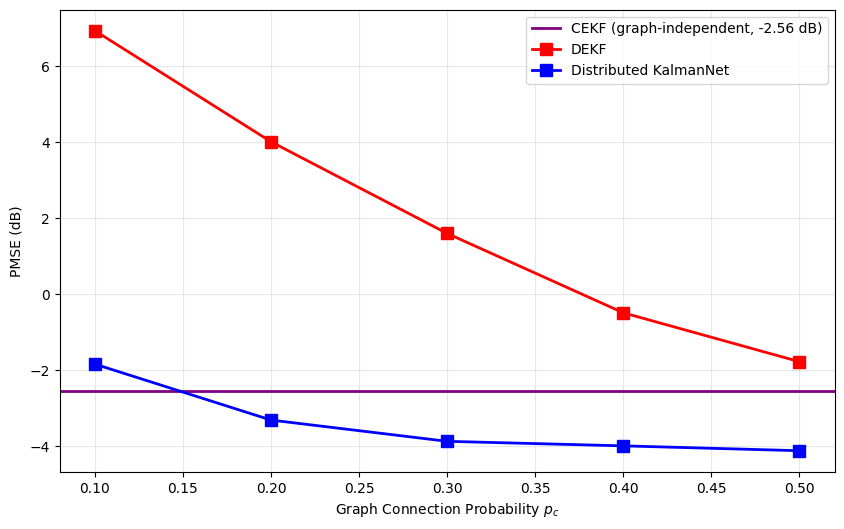

,k_neighbors,p,mean_degree,CEKF,DEKF,Distributed KalmanNet,CEKF_db,DEKF_db,Distributed KalmanNet_db
0,5,0.1,6.44,0.554834,4.946650,0.653848,-2.558372,6.943111,-1.845229
1,10,0.2,12.24,0.554834,2.521089,0.465553,-2.558372,4.015882,-3.320311
2,15,0.3,18.00,0.554834,1.445088,0.409203,-2.558372,1.598942,-3.880611
3,20,0.4,24.04,0.554834,0.892857,0.398093,-2.558372,-0.492182,-4.000154
4,25,0.5,29.92,0.554834,0.663536,0.386510,-2.558372,-1.781355,-4.128387


In [19]:
CONNECTIVITY_R_EVAL = 1.0
# One DKN per connectivity, each trained at its own density and tagged with a
# trailing _c<c> in no_mismatch/. p is the nominal connectivity fraction c / N,
# so the c5 checkpoint sits at p = 0.1 when N = 50.
connectivity_dir = experiment_dir / "no_mismatch"
connectivity_stem = localization_model_name(config_val, CONNECTIVITY_R_EVAL)
connectivity_checkpoints = {
    int(path.stem.rsplit("_c", 1)[1]): path
    for path in connectivity_dir.glob(f"{connectivity_stem}_c*.pth")
}
CONNECTIVITY_K_VALUES = sorted(connectivity_checkpoints)
if not CONNECTIVITY_K_VALUES:
    raise FileNotFoundError(
        f"No per-connectivity checkpoints matching {connectivity_stem}_c*.pth "
        f"in {connectivity_dir}"
    )
print(
    "Connectivity checkpoints: "
    + ", ".join(f"c{c} (p={c / num_nodes:g})" for c in CONNECTIVITY_K_VALUES)
)

connectivity_run_name = dkn_run_name(CONNECTIVITY_R_EVAL)
# The _c checkpoints live in no_mismatch/ and were trained at the true dt, so
# this section ignores the experiment's dt-mismatch setting.
f_data_conn = ConstantVelocityModel(time_delta)
f_model_conn = f_data_conn
connectivity_noise = noise_for_scale(CONNECTIVITY_R_EVAL)
# Node positions and sensor types are held fixed, so h_system and r_array -- and
# therefore the measurements -- are identical at every k. Only the graph changes.
connectivity_r_array = r_array_for(h_system, CONNECTIVITY_R_EVAL)

# Shared trajectories: every k sees identical data, so errors are paired across k.
seed_everything(config_val["seed"] + 80_000)
connectivity_trials = []
for _ in range(num_trials):
    true_x0 = sample_initial_state(x_init, p0)
    traj = generate_trajectory(
        f_data_conn, true_x0, num_time_steps, connectivity_noise["q_matrix"]
    )
    meas = generate_measurements(h_system, traj, connectivity_r_array)
    connectivity_trials.append((traj, meas))

# CEKF is centralized and never touches the graph, so it is a constant reference.
connectivity_errors_cekf = []
for trajectory, measurements in tqdm(connectivity_trials, desc="CEKF reference"):
    x_hat_cekf_c = centralized_extended_kalman_filter(
        measurements=measurements,
        f_system=f_model_conn,
        h_system=h_system,
        r_array=connectivity_r_array,
        q=connectivity_noise["q"],
        p0=p0,
        x0=x_init,
        time_steps=num_time_steps,
        node_num=num_nodes,
        q_matrix=connectivity_noise["q_matrix"],
    )
    connectivity_errors_cekf.append(
        position_error_from_state_sequence(trajectory, x_hat_cekf_c[:, :, 0])
    )
cekf_reference_error = float(np.mean(connectivity_errors_cekf))

connectivity_rows = []
for k_neighbors in CONNECTIVITY_K_VALUES:
    test_adjacency_matrix = create_distance_based_graph(
        node_positions, k_neighbors=k_neighbors, seed=config_val["graph_seed"]
    )
    test_j_matrix = np.array(test_adjacency_matrix, dtype=float, copy=True)
    np.fill_diagonal(test_j_matrix, 1.0)
    # create_distance_based_graph jitters k per node and adds self-loops, so record
    # the realized mean neighbour count with the diagonal excluded.
    mean_degree = float(
        (test_adjacency_matrix.sum() - np.trace(test_adjacency_matrix)) / num_nodes
    )

    # Each density has its own checkpoint, so the model is rebuilt per c.
    connectivity_kalman_process = build_dkn_model(
        config_val, f_model_conn, connectivity_r_array, x_init
    )
    connectivity_kalman_process = load_state_dict_checked(
        connectivity_kalman_process, connectivity_checkpoints[k_neighbors]
    )

    trial_errors_dekf = []
    trial_errors_dkn = []

    for trajectory, measurements in tqdm(connectivity_trials, desc=f"k={k_neighbors}"):
        x_hat_dekf_c = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=f_model_conn,
            h_system=h_system,
            r_array=connectivity_r_array,
            q=connectivity_noise["q"],
            p0=p0,
            x0=x_init,
            j_matrix=test_j_matrix,
            time_steps=num_time_steps,
            node_num=num_nodes,
            q_matrix=connectivity_noise["q_matrix"],
        )
        trial_errors_dekf.append(position_error_from_dekf(trajectory, x_hat_dekf_c))

        graph_data = build_graph_data_for_dkn(
            test_adjacency_matrix, h_system, trajectory, measurements
        )
        with torch.no_grad():
            x_hat_dkn_c = (
                connectivity_kalman_process(graph_data)[0]
                .mean(dim=1)[..., 0]
                .cpu()
                .numpy()
            )
        trial_errors_dkn.append(
            position_error_from_state_sequence(trajectory, x_hat_dkn_c)
        )

    connectivity_rows.append({
        "k_neighbors": k_neighbors,
        "p": k_neighbors / num_nodes,
        "mean_degree": mean_degree,
        "CEKF": cekf_reference_error,
        "DEKF": np.mean(trial_errors_dekf),
        DKN_LABEL: np.mean(trial_errors_dkn),
    })

connectivity_results_df = pd.DataFrame(connectivity_rows)
connectivity_epsilon = np.finfo(float).tiny
for model_name in ["CEKF", "DEKF", DKN_LABEL]:
    connectivity_results_df[f"{model_name}_db"] = 10 * np.log10(
        np.maximum(connectivity_results_df[model_name], connectivity_epsilon)
    )
cekf_reference_error_db = 10 * np.log10(
    max(cekf_reference_error, connectivity_epsilon)
)

connectivity_summary_path = notebook_plot_dir / (
    f"connectivity_per_density_{connectivity_run_name}"
    f"_N={num_nodes}_trials={num_trials}.png"
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(
    y=cekf_reference_error_db,
    color=MODEL_COLORS["CEKF"],
    linestyle="-",
    linewidth=2,
    label=f"CEKF (graph-independent, {cekf_reference_error_db:.2f} dB)",
)
ax.plot(
    connectivity_results_df["p"], connectivity_results_df["DEKF_db"],
    linewidth=2, markersize=8, label="DEKF", **model_style("DEKF"),
)
ax.plot(
    connectivity_results_df["p"], connectivity_results_df[f"{DKN_LABEL}_db"],
    linewidth=2, markersize=8, label=DKN_LABEL, **model_style(DKN_LABEL),
)
ax.set_xlabel(r"Graph Connection Probability $p_c$")
ax.set_ylabel("PMSE (dB)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(connectivity_summary_path, dpi=200, bbox_inches="tight")
print(f"Saved: {connectivity_summary_path}")
plt.show()

connectivity_results_df


## 8. Time-Step Generalization

Evaluate the trained models on shorter, training-length, and longer trajectories without retraining. Every model receives the same paired trials for each horizon, and the vertical reference line marks the number of time steps used during training. Errors are reported as PMSE (dB) with 95% confidence intervals.

In [20]:
TIME_STEPS_R_EVAL = 1.0
TIME_STEPS_VALUES = [20, 40, 80, 100, 200]
TIME_STEPS_DKN_DT_RATIO = default_dkn_dt_ratio if use_dt_mismatch else 1.0

steps_noise = noise_for_scale(TIME_STEPS_R_EVAL)
steps_r_array = r_array_for(h_system, TIME_STEPS_R_EVAL)
steps_data_system = ConstantVelocityModel(time_delta)
steps_model_system = ConstantVelocityModel(
    time_delta * float(TIME_STEPS_DKN_DT_RATIO)
)

steps_dkn_path = dkn_model_path(
    experiment_dir,
    TIME_STEPS_R_EVAL,
    use_dt_mismatch=use_dt_mismatch,
    dt_ratio=TIME_STEPS_DKN_DT_RATIO,
)
if not steps_dkn_path.exists():
    raise FileNotFoundError(
        f"Missing DKN checkpoint for time-step generalization: {steps_dkn_path}"
    )
steps_dkn = build_dkn_model(
    config_val, steps_model_system, steps_r_array, x_init
)
steps_dkn = load_state_dict_checked(steps_dkn, steps_dkn_path).eval()

steps_gnn_rnn = None
steps_gnn_path = gnn_rnn_model_path(experiment_dir, TIME_STEPS_R_EVAL)
if steps_gnn_path.exists():
    steps_gnn_rnn = build_gnn_rnn_model(config_val)
    steps_gnn_rnn = load_state_dict_checked(steps_gnn_rnn, steps_gnn_path).eval()
else:
    print(
        f"No GNN-RNN checkpoint found at {steps_gnn_path}; "
        "omitting it from time-step generalization."
    )

steps_model_names = ["CEKF", "DEKF", DKN_LABEL]
if steps_gnn_rnn is not None:
    steps_model_names.append("GNN-RNN")
steps_rows = []

for test_time_steps in TIME_STEPS_VALUES:
    seed_everything(config_val["seed"] + 70_000)
    trial_errors = {name: [] for name in steps_model_names}
    for _ in tqdm(
        range(num_trials), desc=f"time-step generalization T={test_time_steps}"
    ):
        true_x0 = sample_initial_state(x_init, p0)
        trajectory, measurements = generate_trial_data(
            steps_data_system,
            h_system,
            true_x0,
            test_time_steps,
            steps_noise["q_matrix"],
            steps_r_array,
        )
        x_hat_cekf = centralized_extended_kalman_filter(
            measurements=measurements,
            f_system=steps_model_system,
            h_system=h_system,
            r_array=steps_r_array,
            q=steps_noise["q"],
            p0=p0,
            x0=x_init,
            time_steps=test_time_steps,
            node_num=num_nodes,
            q_matrix=steps_noise["q_matrix"],
        )
        x_hat_dekf = diffusion_extended_kalman_filter_parallel_edge(
            measurements=measurements,
            f_system=steps_model_system,
            h_system=h_system,
            r_array=steps_r_array,
            q=steps_noise["q"],
            p0=p0,
            x0=x_init,
            j_matrix=j_matrix,
            time_steps=test_time_steps,
            node_num=num_nodes,
            q_matrix=steps_noise["q_matrix"],
        )
        graph_data = build_graph_data_for_dkn(
            adjacency_matrix, h_system, trajectory, measurements
        )
        with torch.no_grad():
            x_hat_dkn = steps_dkn(graph_data)[0].mean(dim=1)[..., 0].cpu().numpy()
        trial_errors["CEKF"].append(
            position_error_from_state_sequence(trajectory, x_hat_cekf[:, :, 0])
        )
        trial_errors["DEKF"].append(
            position_error_from_dekf(trajectory, x_hat_dekf)
        )
        trial_errors[DKN_LABEL].append(
            position_error_from_state_sequence(trajectory, x_hat_dkn)
        )
        if steps_gnn_rnn is not None:
            x_hat_gnn_rnn = predict_gnn_rnn(
                steps_gnn_rnn, graph_data, h_system
            )
            trial_errors["GNN-RNN"].append(
                position_error_from_state_sequence(trajectory, x_hat_gnn_rnn)
            )

    for model_name, errors in trial_errors.items():
        errors = np.asarray(errors)
        steps_rows.append({
            "time_steps": test_time_steps,
            "model": model_name,
            "mean_position_error": errors.mean(),
            "std_position_error": errors.std(ddof=1),
            "ci95": 1.96 * errors.std(ddof=1) / np.sqrt(len(errors)),
        })

time_steps_results_df = pd.DataFrame(steps_rows)
epsilon = np.finfo(float).tiny
time_steps_results_df["mean_position_error_db"] = 10 * np.log10(
    np.maximum(time_steps_results_df["mean_position_error"], epsilon)
)
time_steps_results_df["ci95_low_db"] = 10 * np.log10(
    np.maximum(
        time_steps_results_df["mean_position_error"] - time_steps_results_df["ci95"],
        epsilon,
    )
)
time_steps_results_df["ci95_high_db"] = 10 * np.log10(
    np.maximum(
        time_steps_results_df["mean_position_error"] + time_steps_results_df["ci95"],
        epsilon,
    )
)
display(time_steps_results_df)

time_steps_plot_path = notebook_plot_dir / (
    f"time_steps_generalization_trainT={train_time_steps}_trials={num_trials}.png"
)
plt.figure(figsize=(10, 6))
for model_name, rows in time_steps_results_df.groupby("model"):
    rows = rows.sort_values("time_steps")
    mean_db = rows["mean_position_error_db"].to_numpy()
    error_db = np.vstack([
        mean_db - rows["ci95_low_db"].to_numpy(),
        rows["ci95_high_db"].to_numpy() - mean_db,
    ])
    plt.errorbar(
        rows["time_steps"],
        mean_db,
        yerr=error_db,
        capsize=4,
        linewidth=2,
        label=model_name,
        **model_style(model_name),
    )
plt.axvline(
    train_time_steps,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"training T={train_time_steps}",
)
plt.xlabel("Trajectory time steps")
plt.ylabel("PMSE (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(time_steps_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved: {time_steps_plot_path}")
plt.show()

time-step generalization T=20:   0%|          | 0/50 [00:00<?, ?it/s]/Users/inega/Python/kalmanet2/distributedKNET/utils/LocalizationScenario.py:323: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.tensor(trajectory, dtype=torch.float32),
time-step generalization T=20:  46%|████▌     | 23/50 [00:06<00:07,  3.68it/s]


KeyboardInterrupt: 

## 9. Inference-Latency Comparison

Measure wall-clock inference time per trial for CEKF, DEKF, and Distributed KalmanNet on the current device. Distributed KalmanNet uses batched inference via `Batch.from_data_list()`; the classical filters are inherently sequential. The bar chart shows mean per-trial latency +/- one standard deviation.

In [ ]:
import time
from torch_geometric.data import Batch


LATENCY_EXP_DIR = experiment_dir
LATENCY_R = 1.0
LATENCY_DT_RATIO = default_dkn_dt_ratio if use_dt_mismatch else 1.0
LATENCY_NUM_TRIALS = 200
LATENCY_BATCH_SIZE = 50
LATENCY_WARMUP = 5

lat_cfg = load_experiment_config(LATENCY_EXP_DIR)
lat_state_dim  = lat_cfg["state_dimension"]
lat_x_init     = np.array(lat_cfg["x0"], dtype=float).reshape(lat_state_dim, 1)
lat_p0         = np.eye(lat_state_dim) * lat_cfg["p0_scale"]
lat_num_nodes  = lat_cfg["num_nodes"]
lat_time_delta = lat_cfg["time_delta"]
lat_noise      = derive_localization_noise(lat_cfg["mu"], lat_cfg["rho"], LATENCY_R)
lat_T          = experiment_time_steps(lat_cfg)

lat_node_positions = np.array(lat_cfg["node_positions"], dtype=float)
lat_h_system = DistanceAngleObservation(lat_node_positions)
lat_adj = create_distance_based_graph(
    lat_node_positions, k_neighbors=lat_cfg["k_neighbors"], seed=lat_cfg["graph_seed"]
)
lat_j_matrix = np.array(lat_adj, dtype=float, copy=True)
np.fill_diagonal(lat_j_matrix, 1.0)
lat_r_array = measurement_noise_for_nodes(
    lat_h_system, lat_noise["sigma_r"], lat_noise["sigma_theta"]
)
lat_f_system = ConstantVelocityModel(lat_time_delta * LATENCY_DT_RATIO)


lat_dkn_path = dkn_model_path(
    LATENCY_EXP_DIR,
    LATENCY_R,
    use_dt_mismatch=lat_cfg.get("use_dt_mismatch", False),
    dt_ratio=LATENCY_DT_RATIO,
)
if not lat_dkn_path.exists():
    raise FileNotFoundError(f"Missing DKN checkpoint: {lat_dkn_path}")

lat_dkn = build_dkn_model(lat_cfg, lat_f_system, lat_r_array, lat_x_init)
lat_dkn = load_state_dict_checked(lat_dkn, lat_dkn_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lat_dkn = lat_dkn.to(device)
print(f"{DKN_LABEL} device: {device}")


seed_everything(lat_cfg["seed"])
total_trials = LATENCY_NUM_TRIALS + LATENCY_WARMUP * LATENCY_BATCH_SIZE
lat_trials = []
for _ in range(total_trials):
    true_x0 = sample_initial_state(lat_x_init, lat_p0)
    traj = generate_trajectory(lat_f_system, true_x0, lat_T, lat_noise["q_matrix"])
    meas = generate_measurements(lat_h_system, traj, lat_r_array)
    lat_trials.append((traj, meas))


lat_data_list = [
    build_graph_data_for_dkn(lat_adj, lat_h_system, t, m) for t, m in lat_trials
]

for wi in range(LATENCY_WARMUP):
    warm_batch = Batch.from_data_list(
        lat_data_list[wi * LATENCY_BATCH_SIZE : (wi + 1) * LATENCY_BATCH_SIZE]
    ).to(device)
    with torch.no_grad():
        _ = lat_dkn(warm_batch)
sync_torch_device(device)

timing_data   = lat_data_list[LATENCY_WARMUP * LATENCY_BATCH_SIZE:]
timing_trials = lat_trials[LATENCY_WARMUP * LATENCY_BATCH_SIZE:]


cekf_times = []
for traj, meas in tqdm(timing_trials, desc="Timing CEKF"):
    t0 = time.perf_counter()
    _ = centralized_extended_kalman_filter(
        measurements=meas, f_system=lat_f_system, h_system=lat_h_system,
        r_array=lat_r_array, q=lat_noise["q"], p0=lat_p0, x0=lat_x_init,
        time_steps=lat_T, node_num=lat_num_nodes,
        q_matrix=lat_noise["q_matrix"],
    )
    cekf_times.append(time.perf_counter() - t0)


dekf_times = []
for traj, meas in tqdm(timing_trials, desc="Timing DEKF"):
    t0 = time.perf_counter()
    _ = diffusion_extended_kalman_filter_parallel_edge(
        measurements=meas, f_system=lat_f_system, h_system=lat_h_system,
        r_array=lat_r_array, q=lat_noise["q"], p0=lat_p0, x0=lat_x_init,
        j_matrix=lat_j_matrix, time_steps=lat_T, node_num=lat_num_nodes,
        q_matrix=lat_noise["q_matrix"],
    )
    dekf_times.append(time.perf_counter() - t0)


dkn_per_trial_ms = []
for bi in tqdm(range(0, len(timing_data), LATENCY_BATCH_SIZE), desc=f"Timing {DKN_LABEL} (batch)"):
    chunk = timing_data[bi : bi + LATENCY_BATCH_SIZE]
    if not chunk:
        break
    batch = Batch.from_data_list(chunk).to(device)
    sync_torch_device(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = lat_dkn(batch)
    sync_torch_device(device)
    dkn_per_trial_ms.extend([1e3 * (time.perf_counter() - t0) / len(chunk)] * len(chunk))


results_latency = {
    "CEKF":                                        np.array(cekf_times) * 1e3,
    "DEKF":                                        np.array(dekf_times) * 1e3,
    f"{DKN_LABEL} (batch={LATENCY_BATCH_SIZE})":   np.array(dkn_per_trial_ms),
}

latency_df = pd.DataFrame({
    label: {"mean_ms": v.mean(), "std_ms": v.std(), "median_ms": np.median(v)}
    for label, v in results_latency.items()
}).T
print(f"\nInference latency per trial (ms) - device: {device}")
print(latency_df.round(3).to_string())


fig, ax = plt.subplots(figsize=(8, 5))
labels = list(results_latency.keys())
means  = [results_latency[l].mean() for l in labels]
stds   = [results_latency[l].std()  for l in labels]
colors = [model_color(label) for label in labels]
bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, edgecolor="black", linewidth=0.8)
# Break the batch suffix onto its own line so the long model name fits under its bar.
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([label.replace(" (batch=", "\n(batch=") for label in labels])
for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        m + s + max(means) * 0.015,
        f"{m:.2f} ms",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_ylabel("Mean per-trial latency (ms)")
ax.grid(axis="y", alpha=0.35)
ax.set_ylim(0, max(means) * 1.35)

lat_plot_path = notebook_plot_dir / (
    f"inference_latency_r={LATENCY_R}_dtx{LATENCY_DT_RATIO}_batch={LATENCY_BATCH_SIZE}.png"
)
fig.savefig(lat_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved: {lat_plot_path}")
plt.show()

latency_df
